In [1]:
!pip install -q pymupdf sentence-transformers faiss-cpu matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 56.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 72.0 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import fitz
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sentence_transformers import SentenceTransformer

In [3]:
DATA_DIR = "/kaggle/input/datasets/bhargavannem/beyond-possiable"

pdf_paths = list(Path(DATA_DIR).rglob("*.pdf"))

print("Total PDF files:", len(pdf_paths))

for path in pdf_paths:
    print(path)

Total PDF files: 1
/kaggle/input/datasets/bhargavannem/beyond-possiable/Beyond Possible - Nims Purja _Worldfreebooks.com_.pdf


In [4]:
documents = []

for pdf_path in pdf_paths:

    try:
        pdf = fitz.open(str(pdf_path))

        for page_num, page in enumerate(pdf, start=1):

            text = page.get_text().strip()

            if text:
                documents.append({
                    "text": text,
                    "source": pdf_path.name,
                    "page": page_num
                })

        pdf.close()

    except Exception as e:
        print("Error reading:", pdf_path.name, e)

print("Total pages extracted:", len(documents))

Total pages extracted: 227


In [5]:
df = pd.DataFrame(documents)

if not df.empty:
    df["text_length"] = df["text"].str.len()

display(df.head())

print("Dataset shape:", df.shape)

,text,source,page,text_length
0,Nirmal ('Nims') Purja MBE was born in Nepal. H...,Beyond Possible - Nims Purja _Worldfreebooks.c...,2,191
1,"Beyond Possible\n \n \nOne Soldier, Fourteen P...",Beyond Possible - Nims Purja _Worldfreebooks.c...,3,118
2,First published in Great Britain in 2020 by Ho...,Beyond Possible - Nims Purja _Worldfreebooks.c...,4,970
3,Look out for linked text (which is in blue) th...,Beyond Possible - Nims Purja _Worldfreebooks.c...,5,134
4,"To my mother, Purna Kumari Purja, for working ...",Beyond Possible - Nims Purja _Worldfreebooks.c...,6,145


Dataset shape: (227, 4)


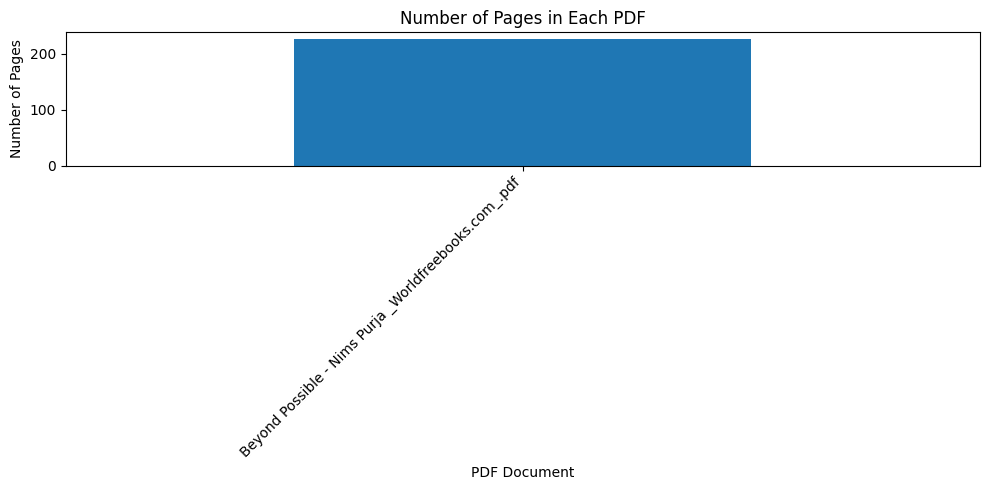

In [6]:
if not df.empty:

    pages_per_pdf = df.groupby("source")["page"].nunique()

    plt.figure(figsize=(10, 5))

    pages_per_pdf.plot(kind="bar")

    plt.title("Number of Pages in Each PDF")
    plt.xlabel("PDF Document")
    plt.ylabel("Number of Pages")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

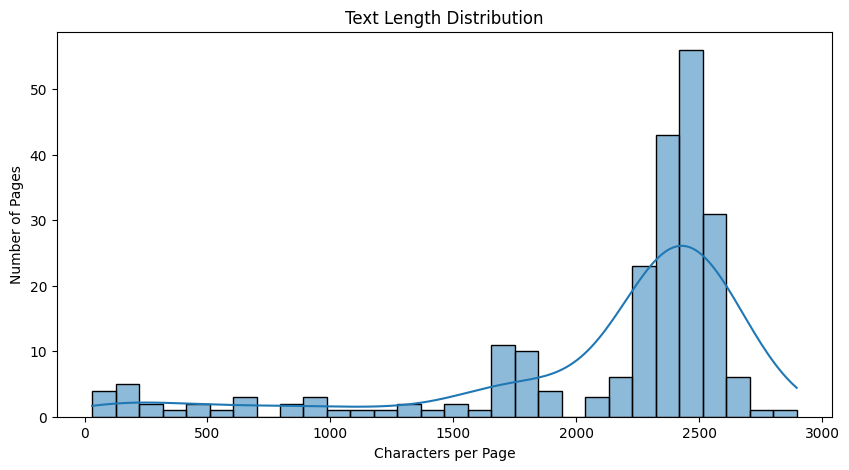

In [7]:
if not df.empty:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x="text_length",
        bins=30,
        kde=True
    )

    plt.title("Text Length Distribution")
    plt.xlabel("Characters per Page")
    plt.ylabel("Number of Pages")

    plt.show()

In [8]:
def split_text(text, chunk_size=500, overlap=100):

    words = text.split()
    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = " ".join(words[start:end])

        if chunk.strip():
            chunks.append(chunk)

        start += chunk_size - overlap

    return chunks

In [9]:
chunks = []

for doc in documents:

    text_chunks = split_text(doc["text"])

    for chunk_id, chunk_text in enumerate(text_chunks):

        chunks.append({
            "text": chunk_text,
            "source": doc["source"],
            "page": doc["page"],
            "chunk_id": chunk_id
        })

chunks_df = pd.DataFrame(chunks)

print("Total chunks:", len(chunks))

display(chunks_df.head())

Total chunks: 389


,text,source,page,chunk_id
0,Nirmal ('Nims') Purja MBE was born in Nepal. H...,Beyond Possible - Nims Purja _Worldfreebooks.c...,2,0
1,"Beyond Possible One Soldier, Fourteen Peaks – ...",Beyond Possible - Nims Purja _Worldfreebooks.c...,3,0
2,First published in Great Britain in 2020 by Ho...,Beyond Possible - Nims Purja _Worldfreebooks.c...,4,0
3,Look out for linked text (which is in blue) th...,Beyond Possible - Nims Purja _Worldfreebooks.c...,5,0
4,"To my mother, Purna Kumari Purja, for working ...",Beyond Possible - Nims Purja _Worldfreebooks.c...,6,0


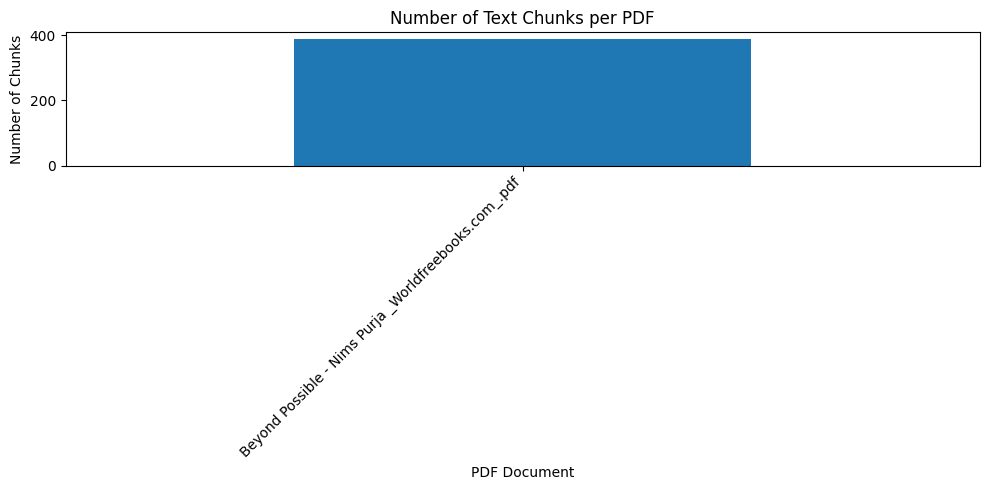

In [10]:
if not chunks_df.empty:

    chunk_counts = chunks_df["source"].value_counts()

    plt.figure(figsize=(10, 5))

    chunk_counts.plot(kind="bar")

    plt.title("Number of Text Chunks per PDF")
    plt.xlabel("PDF Document")
    plt.ylabel("Number of Chunks")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [11]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [12]:
if chunks:

    texts = chunks_df["text"].tolist()

    embeddings = embedding_model.encode(
        texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True
    )

    embeddings = embeddings.astype("float32")

    print("Embedding shape:", embeddings.shape)

else:
    print("No text chunks available.")

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Embedding shape: (389, 384)


In [13]:
if chunks:

    dimension = embeddings.shape[1]

    index = faiss.IndexFlatIP(dimension)

    index.add(embeddings)

    print("FAISS index created!")
    print("Total vectors:", index.ntotal)

else:
    print("No embeddings available.")

FAISS index created!
Total vectors: 389


In [22]:
def retrieve_documents(question, top_k=3):

    if not chunks:
        return []

    question_embedding = embedding_model.encode(
        [question],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    k = min(top_k, len(chunks))

    scores, indices = index.search(
        question_embedding,
        k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        if idx >= 0:
            result = chunks[idx].copy()

            result["similarity"] = float(score)

            results.append(result)

    return results

In [ ]:
question = input("Enter your question: ")

results = retrieve_documents(question)

if results:

    print("\nRelevant information:\n")

    for i, result in enumerate(results, start=1):

        print(f"Result {i}")
        print("Source:", result["source"])
        print("Page:", result["page"])
        print("Similarity:", round(result["similarity"], 3))
        print("Text:", result["text"])
        print("-" * 60)

else:
    print("No relevant documents found.")

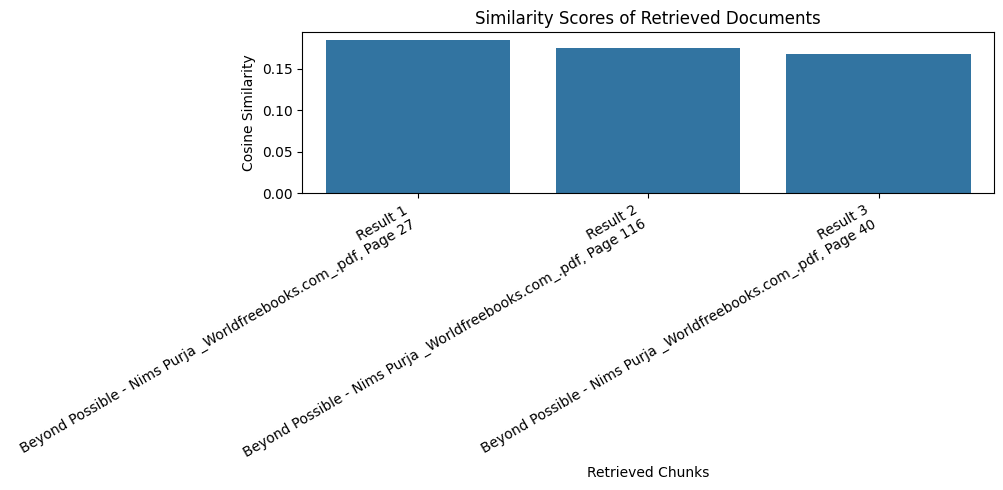

In [20]:
if results:

    result_df = pd.DataFrame(results)

    result_df["label"] = [
        f"Result {i}\n{row['source']}, Page {row['page']}"
        for i, row in enumerate(results, start=1)
    ]

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=result_df,
        x="label",
        y="similarity"
    )

    plt.title("Similarity Scores of Retrieved Documents")
    plt.xlabel("Retrieved Chunks")
    plt.ylabel("Cosine Similarity")

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [21]:
if results:

    results_df = pd.DataFrame(results)

    display(
        results_df[
            ["source", "page", "similarity", "text"]
        ]
    )

,source,page,similarity,text
0,Beyond Possible - Nims Purja _Worldfreebooks.c...,27,0.184523,I’d needed to pass my Nepalese School Leaving ...
1,Beyond Possible - Nims Purja _Worldfreebooks.c...,116,0.174548,for an afternoon.
2,Beyond Possible - Nims Purja _Worldfreebooks.c...,40,0.167918,"back, knowing it was all part of the test. I c..."


In [17]:
questions = [
    "What is the minimum attendance requirement?",
    "What are the examination rules?",
    "What are the semester regulations?"
]

for question in questions:

    print("\nQUESTION:", question)

    results = retrieve_documents(question)

    for result in results:

        print("\nSource:", result["source"])
        print("Page:", result["page"])
        print("Text:", result["text"][:300])


QUESTION: What is the minimum attendance requirement?

Source: Beyond Possible - Nims Purja _Worldfreebooks.com_.pdf
Page: 196
Text: about the protocols of meeting people in authority; I understood the finer details of respect, the importance of civility and cultural integration. I also appreciated the value of people’s time. Mr Kumar was a busy man and there was a limited window in which to

Source: Beyond Possible - Nims Purja _Worldfreebooks.com_.pdf
Page: 114
Text: 3 at 6 a.m. and it was vitally important we left on time if we were to meet it. If we arrived too early, Dr Chin would have to hang around, his body exposed to the wind and cold; get there too late and

Source: Beyond Possible - Nims Purja _Worldfreebooks.com_.pdf
Page: 47
Text: in London.

QUESTION: What are the examination rules?

Source: Beyond Possible - Nims Purja _Worldfreebooks.com_.pdf
Page: 27
Text: I’d needed to pass my Nepalese School Leaving Certificate, which educationally fell somewhere between GCSEs and A

In [18]:
os.makedirs("/kaggle/working", exist_ok=True)

df.to_csv(
    "/kaggle/working/extracted_documents.csv",
    index=False
)

chunks_df.to_csv(
    "/kaggle/working/document_chunks.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [19]:
if chunks:

    faiss.write_index(
        index,
        "/kaggle/working/university.index"
    )

    print("FAISS index saved successfully!")

FAISS index saved successfully!
